## __End to end code for ML:  EDA,  Train,  Deploy (API)__
### __Create separate Standard Functions code for:__


#### 1) Basic Data Cleaning:
* Check Null
  
* Set categorical column


#### 2) EDA code:
* Data Distribution (numerical,categories)
    
* Data Drifting (evidently package) 

* Multicollinearity



#### 3)Training code:
* ML Flow
    - Regression
    - Tree Based
    - Neural Networks



#### 3) Deploy (API)

In [1]:
import numpy as np
print('numpy version:',np.__version__)
import pandas as pd
print('pandas version:',pd.__version__)
from pandasql import sqldf

from IPython.display import display
pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.get_option("display.max_rows")

import seaborn as sns
#get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt

import datetime


from sklearn import tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, auc, roc_curve, roc_auc_score, f1_score, accuracy_score,precision_score,recall_score,classification_report


import random
from sklearn.tree import _tree
from sklearn import tree
from sklearn.model_selection import train_test_split


# CLASSIFIERS
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
print('xgboost version:',xgb.__version__)
from xgboost import XGBClassifier
#import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
#from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import sys, os
from pathlib import Path, PurePath, PureWindowsPath
import shutil
import csv
from os import listdir
from os.path import isfile, join
import glob
import collections


def getTime():
    import datetime
    return datetime.datetime.now().replace(microsecond=0)


startTime=getTime()

# ml functions 
import mlfuncs as ml



random_settings = 1234

numpy version: 1.26.4
pandas version: 2.2.2
xgboost version: 2.1.1


### READ DATA:

In [2]:
data_file_path = 'fraudTrain.csv'


df  = pd.read_csv(data_file_path)

print(df.shape)
print(df.dtypes)
df.head()

(1296675, 23)
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
                          ...   
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
Length: 23, dtype: object


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### CHECK NULL:

In [3]:
ml.checkNull(df)

,Unnamed: 0,zip,merch_long,merch_lat,unix_time,trans_num,dob,job,city_pop,long,lat,state,trans_date_trans_time,city,street,gender,last,first,amt,category,merchant,cc_num,is_fraud
Total_Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent_Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### TO_DATETIME COLS:

In [4]:
date_cols = ['trans_date_trans_time']

df = ml.colsToDateTime(df,date_cols)

df[date_cols].dtypes

trans_date_trans_time    datetime64[ns]
dtype: object

### TO CATEGORY COLS:

In [5]:
df = ml.objectToCategoryCols(df)
df.dtypes

Unnamed: 0                        int64
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                       category
category                       category
                              ...      
trans_num                      category
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
Length: 23, dtype: object

In [ ]:
# not now
### DATA CLEANING
### FEATURE ENGINEERING 

### SET TARGET & FEATURES:

In [6]:
target = 'is_fraud'
features = ['cc_num', 'merchant', 'category', 'amt']

### SPLIT DATA
* TRAIN (default parameters)
* VALIDATION (hyperparameters tuning)
* TEST (check performance)

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = ml.train_val_test_split(df,features,target)

### CLASS WEIGHTS:

In [ ]:
class_weights = get_class_weights(y_train)

{0: 0.5029110678200125, 1: 86.37913970308337}


### MODELS TRAINING:

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

# Instantiate the models
logreg_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(enable_categorical=True,random_state=42)
lgbm_model = LGBMClassifier(random_state=42)
svm_model = SVC(random_state=42)

# Store the models in a dictionary
models = {
    #"Logistic Regression": logreg_model,
    #"Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    #"Support Vector Machine": svm_model,
}

# Train the models
for name, model in models.items():
    print('\nStart:',name)
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")


Start: XGBoost
XGBoost trained successfully.

Start: LightGBM
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 5254, number of negative: 902418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1200
[LightGBM] [Info] Number of data points in the train set: 907672, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005788 -> initscore=-5.146088
[LightGBM] [Info] Start training from score -5.146088
LightGBM trained successfully.


In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, make_scorer

# Define parameter grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'subsample': [0.8, 0.9, 1.0]
    },
    "LightGBM": {
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 200],
        'num_leaves': [31, 63, 127],
        'max_depth': [3, 6, 9]
    },
    "Support Vector Machine": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.1, 1]
    }
}

# Define a custom scorer (optional)
f1_scorer = make_scorer(f1_score, average='weighted')


best_params = {}
best_estimators = {}

# Perform hyperparameter tuning for each model
for name, model in models.items():
    if name == "Logistic Regression":
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], scoring=f1_scorer, cv=5)
    elif name == "Support Vector Machine":
        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=10, scoring=f1_scorer, cv=3, random_state=42)
    else:
        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grids[name], n_iter=10, scoring=f1_scorer, cv=3, random_state=42)
    grid_search.fit(X_val, y_val)
    best_params[name] = grid_search.best_params_
    best_estimators[name] = grid_search.best_estimator_
    print(f"\nBest hyperparameters for {name}: {best_params[name]}")
    print(f"Best score for {name}: {grid_search.best_score_}\n")

In [25]:
best_params

{'XGBoost': {'subsample': 0.9,
  'n_estimators': 200,
  'max_depth': 6,
  'learning_rate': 0.2},
 'LightGBM': {'num_leaves': 31,
  'n_estimators': 100,
  'max_depth': 3,
  'learning_rate': 0.1}}

In [26]:
best_estimators

{'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.2, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=6, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, random_state=42, ...),
 'LightGBM': LGBMClassifier(max_depth=3, random_state=42)}

XGBoost
================= Model Evaluation: AUC & Logloss ==================================
AUC = 0.9908356324523272
logloss = 0.012710696015040539


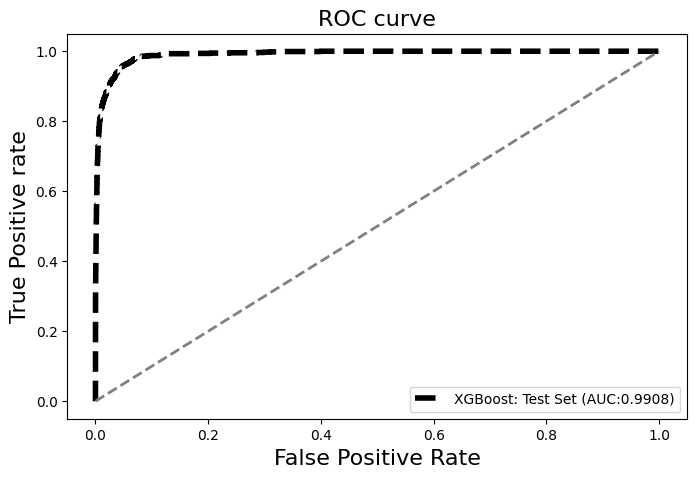

LightGBM
================= Model Evaluation: AUC & Logloss ==================================
AUC = 0.9761576114040906
logloss = 0.014464816166419776


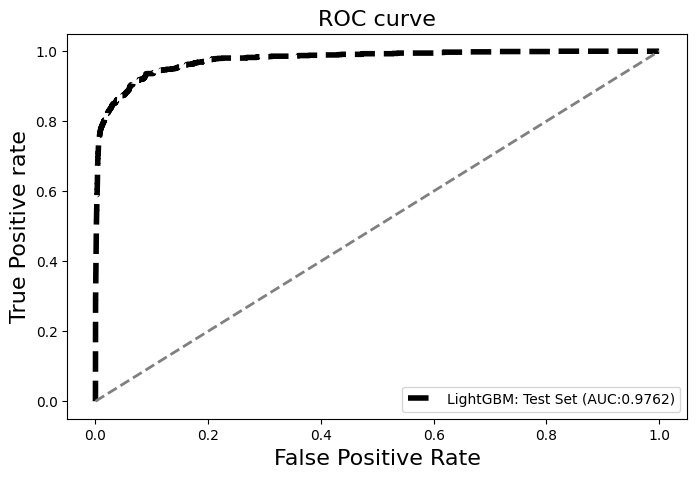

In [36]:
for k in best_estimators.keys():
    print(k)
    y_pred_prob = best_estimators[k].predict_proba(X_test)[:,1]
    #y_pred = best_estimators[k].predict(X_test)
    ml.auc_logloss(y_test, y_pred_prob)
    ml.plot_roc_curve(f'{k}: Test Set',y_test,y_pred_prob)
    #ml.confusionMatrix(y_test,y_pred,f'{k}: Test Set')


XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.70      0.48      0.57      1126

    accuracy                           1.00    194502
   macro avg       0.85      0.74      0.78    194502
weighted avg       1.00      1.00      1.00    194502


LightGBM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    193376
           1       0.70      0.44      0.54      1126

    accuracy                           1.00    194502
   macro avg       0.85      0.72      0.77    194502
weighted avg       1.00      1.00      1.00    194502



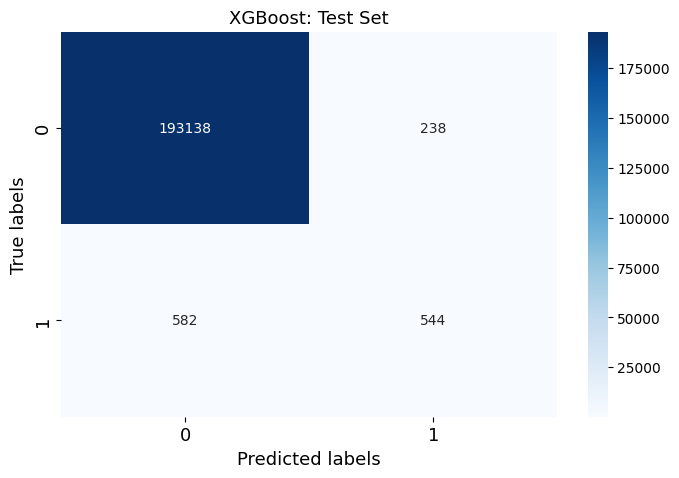

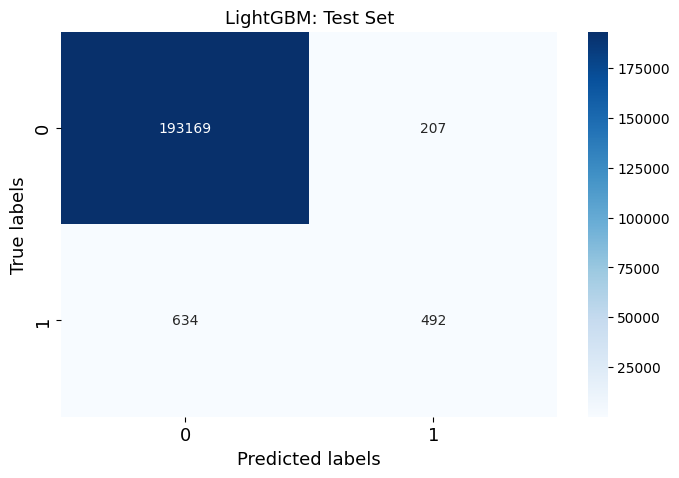

In [38]:
for k in best_estimators.keys():
    print(f'\n{k}')
    y_pred = best_estimators[k].predict(X_test)
    print(classification_report(y_test,y_pred))
    ml.confusionMatrix(y_test,y_pred,f'{k}: Test Set')

In [ ]:
#develop a machine learning model to predict 'default.payment.next.month' and only use Logistic Regression, Random Forest, XGBoost and Support Vector Machine for training

In [12]:
#for DecisionTree, RandomForest , XGB
tree_max_depth = len(features)
n_trees=250 

In [ ]:
# XGBClassifier

#start_train = getTime()
xgbc = xgb.XGBClassifier(#objective='multi:softmax',
                        eval_metric='logloss',
                        #colsample_bytree = 0.9,
                        #gamma = 0.5,
                        max_depth= tree_max_depth,
                        n_estimators= n_trees,
                        learning_rate = 0.01, #xgb_learn_rate,
                        #scale_pos_weight =  sample_weight,
                        subsample = 0.8,
                        #min_child_weight=5,
                        random_state=1234,
                        #use_label_encoder=True,
                        enable_categorical=True
                        )
#print(xgbc)
xgbc = xgbc.fit(X_train,y_train)

In [ ]:
# Predict Validation Set Performance
y_pred_prob = xgbc.predict_proba(X_val)[:,1]
# SEARCH FOR PROBABILITY CUT-OFF FOR CLASSIFICATION
evaluate_df = ml.confMatrix_ByThresholds(y_val,y_pred_prob,1,0)

In [ ]:
threshold,eval_df_dedup,min_metric = ml.minFalseNegRate(evaluate_df)
eval_df_dedup

In [ ]:
# AUC, logloss
ml.auc_logloss(y_val, y_pred_prob)
ml.plot_roc_curve('XGB: Validation Set',y_val,y_pred_prob)
y_pred = np.where(y_pred_prob>threshold,1,0)
print(classification_report(y_val,y_pred))
ml.confusionMatrix(y_val,y_pred,'XGB: Val Set')


In [ ]:
# Predict Test Set Performance

#y_pred =  xgbc.predict(X_test)
y_pred_prob = xgbc.predict_proba(X_test)[:,1]


In [ ]:
ml.auc_logloss(y_test, y_pred_prob)
ml.plot_roc_curve('XGB: Test Set',y_test,y_pred_prob)


y_pred = np.where(y_pred_prob>threshold,1,0)
print(classification_report(y_test,y_pred))
ml.confusionMatrix(y_test,y_pred,'XGB: Test Set')